# AI Product Intelligence System

**What this notebook does:**

In class, we built a Product Intelligence System that understands product images using BLIP, generates captions, and finds similar products using CLIP embeddings + FAISS.

This notebook builds on the Product Intelligence System developed during the bootcamp and extends it with three advanced features:

| | Task | Problem Solved | Extension Method |
|--|------|---------------|------------------|
| 🔵 Base | Product Understanding | Understand images, generate captions | BLIP captioning |
| 🔵 Base | Embedding + Search | Find visually similar products | CLIP + FAISS |
| 🟢 Extension | **Task 1** — Recommendations | Suggest complementary products | CLIP similarity + Outfit Affinity Score |
| 🟢 Extension | **Task 2** — Deduplication | Remove duplicate listings | Agglomerative clustering on CLIP embeddings |
| 🟢 Extension | **Task 3** — Text Search | Search products using natural language | CLIP text-image shared embedding space |

**Tech Stack:** `BLIP` · `CLIP (ViT-B/32)` · `FAISS` · `scikit-learn` · `matplotlib` · `pandas`

*Fully self-contained — no external APIs required*

---
##  Setup & Imports

In [57]:
!pip install -q transformers accelerate sentencepiece faiss-cpu Pillow scikit-learn matplotlib torch torchvision

In [58]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from collections import defaultdict
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
import faiss
import torch
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    CLIPProcessor,
    CLIPModel,
)
import warnings
warnings.filterwarnings('ignore')


N_PRODUCTS    = 700
DUP_THRESHOLD = 0.92      # Cosine similarity above this = duplicate
TOP_K         = 5         # Results to show per query
N_BLIP_DEMO   = 8         # Products to show in BLIP caption demo

DATASET_PATH = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"
IMAGES_PATH = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"

PALETTE = {
    "bg":     "#0f0f0f",
    "panel":  "#1a1a2e",
    "accent": "#00e5ff",
    "warn":   "#e94560",
    "muted":  "#a0a0c0",
    "gold":   "#f5a623",
    "green":  "#7ed321",
    "blue":   "#4a90d9",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device        : {device}")
print(f"Products      : {N_PRODUCTS}")
print(f"Dup threshold : {DUP_THRESHOLD}")

Device        : cuda
Products      : 700
Dup threshold : 0.92


In [14]:
import os

print(os.path.exists(os.path.join(DATASET_PATH, "styles.csv")))
print(os.path.exists(IMAGES_PATH))

True
True


In [15]:
styles_df = pd.read_csv(os.path.join(DATASET_PATH, "styles.csv"), on_bad_lines='skip')

In [16]:
print(styles_df.shape)

(44424, 10)


In [17]:
import os

print(os.listdir('/kaggle/input/datasets/paramaggarwal'))

['fashion-product-images-small']


In [18]:
import os

print(os.listdir('/kaggle/input/datasets/paramaggarwal/fashion-product-images-small'))

['myntradataset', 'images', 'styles.csv']


In [19]:
styles_df = styles_df.dropna(subset=["id", "productDisplayName", "masterCategory", "subCategory"])

available_ids = set(
    int(f.stem) for f in Path(IMAGES_PATH).glob("*.jpg") if f.stem.isdigit()
)

styles_df = styles_df[styles_df["id"].isin(available_ids)].reset_index(drop=True)
styles_df = styles_df.head(N_PRODUCTS)

print(f"Loaded {len(styles_df)} products")

Loaded 700 products


In [20]:
print(styles_df.shape)

(700, 10)


---
##  Load Dataset

**Objective:** Load product metadata and filter to items that have a matching image file.

**Approach:** Cross-reference `styles.csv` IDs with available `.jpg` files in the images directory.

**Expected Output:** A clean DataFrame of N products with name, category, colour, and gender fields.

In [21]:
styles_df = pd.read_csv(os.path.join(DATASET_PATH, "styles.csv"), on_bad_lines='skip')
styles_df = styles_df.dropna(subset=["id", "productDisplayName", "masterCategory", "subCategory"])

available_ids = set(
    int(f.stem) for f in Path(IMAGES_PATH).glob("*.jpg") if f.stem.isdigit()
)
styles_df = styles_df[styles_df["id"].isin(available_ids)].reset_index(drop=True)
styles_df = styles_df.head(N_PRODUCTS)

print(f"Loaded {len(styles_df)} products")
print(f"Categories: {styles_df['masterCategory'].nunique()} master, {styles_df['subCategory'].nunique()} sub")
print()
styles_df[["id", "productDisplayName", "masterCategory", "subCategory", "baseColour", "gender"]].head(8)

Loaded 700 products
Categories: 5 master, 28 sub



,id,productDisplayName,masterCategory,subCategory,baseColour,gender
0,15970,Turtle Check Men Navy Blue Shirt,Apparel,Topwear,Navy Blue,Men
1,39386,Peter England Men Party Blue Jeans,Apparel,Bottomwear,Blue,Men
2,59263,Titan Women Silver Watch,Accessories,Watches,Silver,Women
3,21379,Manchester United Men Solid Black Track Pants,Apparel,Bottomwear,Black,Men
4,53759,Puma Men Grey T-shirt,Apparel,Topwear,Grey,Men
5,1855,Inkfruit Mens Chain Reaction T-shirt,Apparel,Topwear,Grey,Men
6,30805,Fabindia Men Striped Green Shirt,Apparel,Topwear,Green,Men
7,26960,Jealous 21 Women Purple Shirt,Apparel,Topwear,Purple,Women


---
## Base System: Product Understanding with BLIP


**Objective:** Understand what each product image contains by generating a natural language caption.

**Approach:** Load `Salesforce/blip-image-captioning-base`, pass each product image through it, and generate a descriptive caption. This is the "understanding products from images" step from class.

**Expected Output:** Each product image paired with an AI-generated caption describing it.

In [55]:
print("Loading BLIP (image captioning)...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model     = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)
blip_model.eval()
print("BLIP ready ")


def generate_caption(image_path: str) -> str:
    """Generate a natural language caption for a product image using BLIP."""
    try:
        img    = Image.open(image_path).convert("RGB")
        inputs = blip_processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            out = blip_model.generate(**inputs, max_new_tokens=40)
        return blip_processor.decode(out[0], skip_special_tokens=True)
    except Exception:
        return "caption unavailable"

Loading BLIP (image captioning)...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP ready 


  [Fragrance] David Beckham Signature Men Deos
  Caption: a bottle of serum in a white background

  [Bottomwear] Peter England Men Party Black Jeans
  Caption: a man in a grey shirt and black pants

  [Flip Flops] Lotto Women Red & Orange Disco Holic Fli
  Caption: a pair of red flip flops

  [Topwear] Gini and Jony Kids Boys Check Blue Shirt
  Caption: a shirt with a hoodie on it

  [Bags] Baggit Women Umbrella Dum Brown Handbag
  Caption: the sak leather handbag

  [Sandal] Fila Men Camper Brown Sandals
  Caption: te te te te te te te te te te te te te te te te te te te te te te te te te te te te

  [Topwear] Lee Women Paula Blue Top
  Caption: a woman in a blue shirt and jeans

  [Innerwear] Bwitch Beige Full-Coverage Bra BW335
  Caption: a woman in a bikini top and shorts



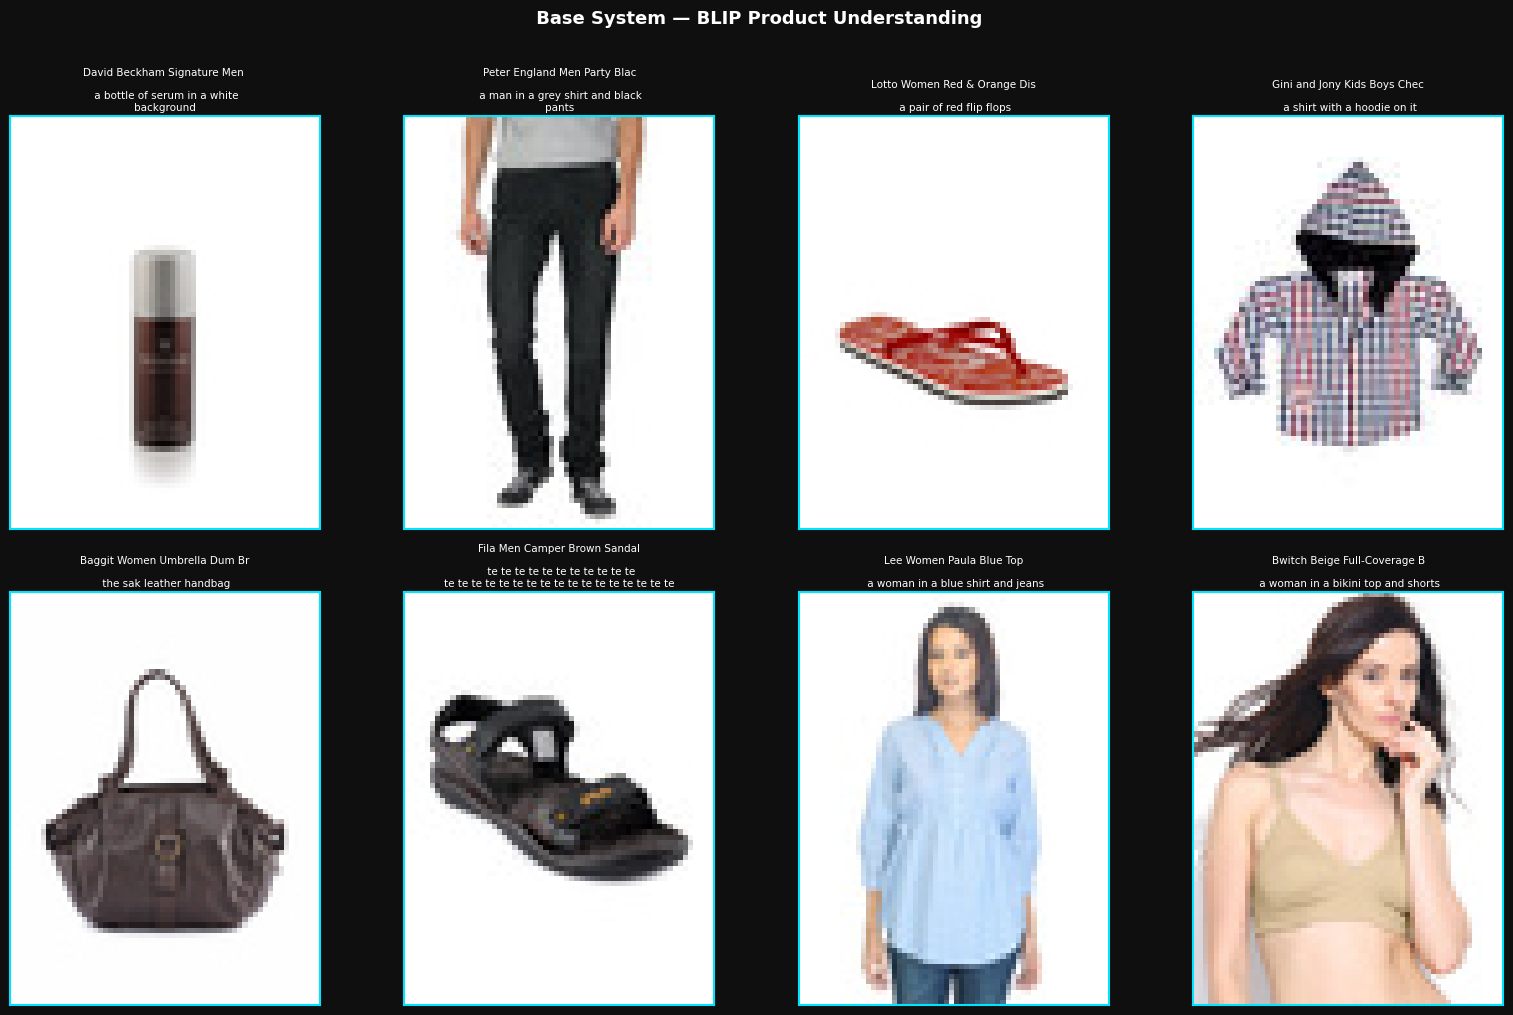

 BLIP caption demo saved.


In [53]:
# Generate captions for a sample of products and display them
sample_idxs = random.sample(range(len(styles_df)), N_BLIP_DEMO)
sample_rows = styles_df.iloc[sample_idxs].reset_index(drop=True)

captions = []
for _, row in sample_rows.iterrows():
    cap = generate_caption(os.path.join(IMAGES_PATH, f"{int(row['id'])}.jpg"))
    captions.append(cap)
    print(f"  [{row['subCategory']}] {row['productDisplayName'][:40]}")
    print(f"  Caption: {cap}\n")

sample_rows["blip_caption"] = captions

# ── Visual display: image + caption ──────────────────────────────────────────
cols = 4
rows = (N_BLIP_DEMO + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))
fig.patch.set_facecolor(PALETTE["bg"])
axes = axes.flatten()

for i, (_, row) in enumerate(sample_rows.iterrows()):
    ax  = axes[i]
    p   = os.path.join(IMAGES_PATH, f"{int(row['id'])}.jpg")
    try:
        ax.imshow(Image.open(p).convert("RGB"))
    except Exception:
        ax.set_facecolor("#333")
    ax.axis("off")
    name    = row["productDisplayName"][:28]
    caption = row["blip_caption"]
    # Wrap long captions
    if len(caption) > 35:
        mid     = caption[:35].rfind(" ")
        caption = caption[:mid] + "\n" + caption[mid+1:]
    ax.set_title(f"{name}\n\n {caption}",
                 color="white", fontsize=7.5, pad=5,
                 loc="center", wrap=True)
    for sp in ax.spines.values():
        sp.set_edgecolor(PALETTE["accent"]); sp.set_linewidth(1.5)
    ax.set_axis_on(); ax.set_xticks([]); ax.set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(" Base System — BLIP Product Understanding",
             color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("base_blip_captions.png", bbox_inches="tight",
            facecolor=PALETTE["bg"], dpi=150)
plt.show()
print(" BLIP caption demo saved.")

---
## Base System: CLIP Embeddings + FAISS Search

*(Replicating what was built in class)*

**Objective:** Generate a vector embedding for every product and build a searchable index.

**Approach:** CLIP ViT-B/32 encodes each image into a 512-dim vector, L2-normalised so cosine similarity = dot product. FAISS indexes these for millisecond-speed search.

**Expected Output:** `embeddings` array of shape `(N, 512)` + FAISS index ready to search.

In [56]:
print("Loading CLIP ViT-B/32...")
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("CLIP ready ")


def get_image_embedding(image_path: str):
    try:
        img = Image.open(image_path).convert("RGB")

        inputs = clip_processor(
            images=img,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            feat = clip_model.get_image_features(**inputs)

        # FIX FOR YOUR TRANSFORMERS VERSION
        if hasattr(feat, "pooler_output"):
            feat = feat.pooler_output

        feat = feat / torch.norm(feat, dim=-1, keepdim=True)

        return feat.cpu().numpy().flatten()

    except Exception as e:
        print("ERROR:", e)
        return None


def get_text_embedding(text: str):
    """Return L2-normalised 512-dim CLIP text embedding."""

    inputs = clip_processor(
        text=[text],
        return_tensors="pt",
        truncation=True
    ).to(device)

    with torch.no_grad():
        feat = clip_model.get_text_features(**inputs)

    if hasattr(feat, "pooler_output"):
        feat = feat.pooler_output

    feat = feat / feat.norm(dim=-1, keepdim=True)

    return feat.cpu().numpy().flatten()


# Embed all products
embeddings, valid_rows = [], []
for i, (_, row) in enumerate(styles_df.iterrows()):
    emb = get_image_embedding(os.path.join(IMAGES_PATH, f"{int(row['id'])}.jpg"))
    if emb is not None:
        embeddings.append(emb)
        valid_rows.append(row)
    if (i + 1) % 100 == 0:
        print(f"  Embedded {i+1}/{len(styles_df)}...")

embeddings  = np.array(embeddings, dtype="float32")
products_df = pd.DataFrame(valid_rows).reset_index(drop=True)

print(f"\nEmbedding matrix: {embeddings.shape}  (products × dims)")

Loading CLIP ViT-B/32...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP ready 
  Embedded 100/700...
  Embedded 200/700...
  Embedded 300/700...
  Embedded 400/700...
  Embedded 500/700...
  Embedded 600/700...
  Embedded 700/700...

Embedding matrix: (700, 512)  (products × dims)


In [33]:
sample_id = int(styles_df.iloc[0]["id"])

emb = get_image_embedding(
    os.path.join(IMAGES_PATH, f"{sample_id}.jpg")
)

print(type(emb))
print(emb.shape if emb is not None else None)

<class 'numpy.ndarray'>
(512,)


In [27]:
from PIL import Image
import os

sample_id = int(styles_df.iloc[0]["id"])
img_path = os.path.join(IMAGES_PATH, f"{sample_id}.jpg")

print(img_path)
print(os.path.exists(img_path))

img = Image.open(img_path)
print(img.size)

/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images/15970.jpg
True
(60, 80)


In [34]:
# Build FAISS index
dim   = embeddings.shape[1]     # 512 for CLIP ViT-B/32
index = faiss.IndexFlatIP(dim)  # Inner product on L2-normalised vecs = cosine similarity
index.add(embeddings)
print(f"FAISS index: {index.ntotal} vectors | dim={dim} | IndexFlatIP ✓")

FAISS index: 700 vectors | dim=512 | IndexFlatIP ✓


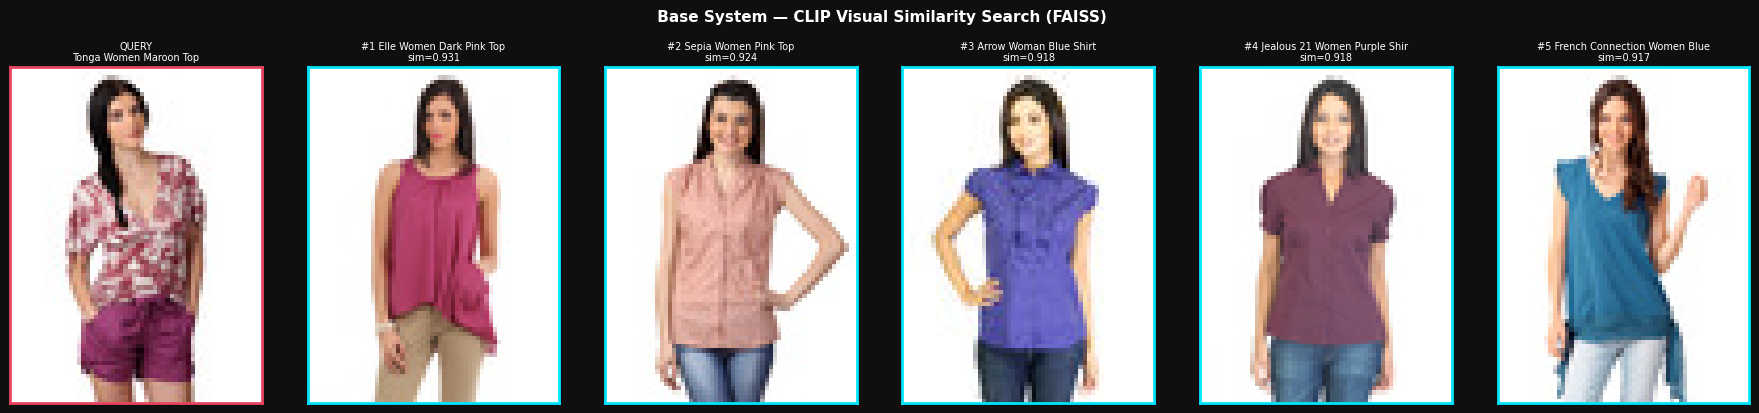


 Base system complete. Now extending with three advanced features...


In [52]:
# ── Demo: Find visually similar products (as done in class) ───────────────────
def show_similar_products(query_idx: int, top_k: int = 5):
    """Given a product index, display the top-k most visually similar products."""
    query_emb        = embeddings[query_idx].reshape(1, -1)
    sims, idxs       = index.search(query_emb, top_k + 1)
    # Remove the query itself from results
    results = [(idx, sim) for idx, sim in zip(idxs[0], sims[0]) if idx != query_idx][:top_k]

    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 4))
    fig.patch.set_facecolor(PALETTE["bg"])

    def show(ax, prod_id, title, border=PALETTE["accent"]):
        p = os.path.join(IMAGES_PATH, f"{int(prod_id)}.jpg")
        try:
            ax.imshow(Image.open(p).convert("RGB"))
        except Exception:
            ax.set_facecolor("#333")
        ax.axis("off")
        ax.set_title(title, color="white", fontsize=7, pad=4)
        for sp in ax.spines.values():
            sp.set_edgecolor(border); sp.set_linewidth(2)
        ax.set_axis_on(); ax.set_xticks([]); ax.set_yticks([])

    q_name = products_df.loc[query_idx, "productDisplayName"][:28]
    show(axes[0], products_df.loc[query_idx, "id"],
         f"QUERY\n{q_name}", border=PALETTE["warn"])

    for i, (idx, sim) in enumerate(results):
        name = products_df.loc[idx, "productDisplayName"][:28]
        show(axes[i+1], products_df.loc[idx, "id"],
             f"#{i+1} {name}\nsim={sim:.3f}")

    plt.suptitle(" Base System — CLIP Visual Similarity Search (FAISS)",
                 color="white", fontsize=11, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("base_similarity_search.png", bbox_inches="tight",
                facecolor=PALETTE["bg"], dpi=150)
    plt.show()


show_similar_products(random.randint(0, len(products_df) - 1))
print("\n Base system complete. Now extending with three advanced features...")

---
# Extensions — Advanced Features

The base system finds visually similar products. The three tasks below extend it with:
- **Task 1:** Complementary product recommendations (not just similar)
- **Task 2:** Automatic deduplication of the product catalog
- **Task 3:** Natural language text search across the catalog

All three reuse the same CLIP embeddings and FAISS index built above — no additional models needed.

---
#  Task 1 — Smart Product Recommendation Engine

**Objective:** Given any product, surface the best *complementary* items — not just visually similar ones.

**Approach:** Blend two signals — (1) CLIP visual similarity via FAISS, and (2) an Outfit Affinity Score that rewards cross-category pairings (shirt+jeans scores higher than shirt+shirt). Final score = 50% visual + 50% affinity.

**Expected Output:** Ranked recommendations with score breakdown and a human-readable reason per result.


 Input: Catwalk Women Brown Sandals (Shoes)
Rank  Product                                Category        Final  Visual  Affinity
──────────────────────────────────────────────────────────────────────────────────
1     Rocia Women Black Flats                Shoes          0.6357  0.9715      0.30
       Frequently purchased together with shoes products.
2     Rocia Women Black & Brown Sandals      Shoes          0.6333  0.9665      0.30
       Frequently purchased together with shoes products.
3     Rocia Women Beige Flats                Shoes          0.6317  0.9633      0.30
       Frequently purchased together with shoes products.
4     Gliders Men Brown Leather Sandals      Sandal         0.6290  0.9580      0.30
       Frequently purchased together with shoes products.
5     Catwalk Women Brown Sandals            Shoes          0.6289  0.9577      0.30
       Frequently purchased together with shoes products.


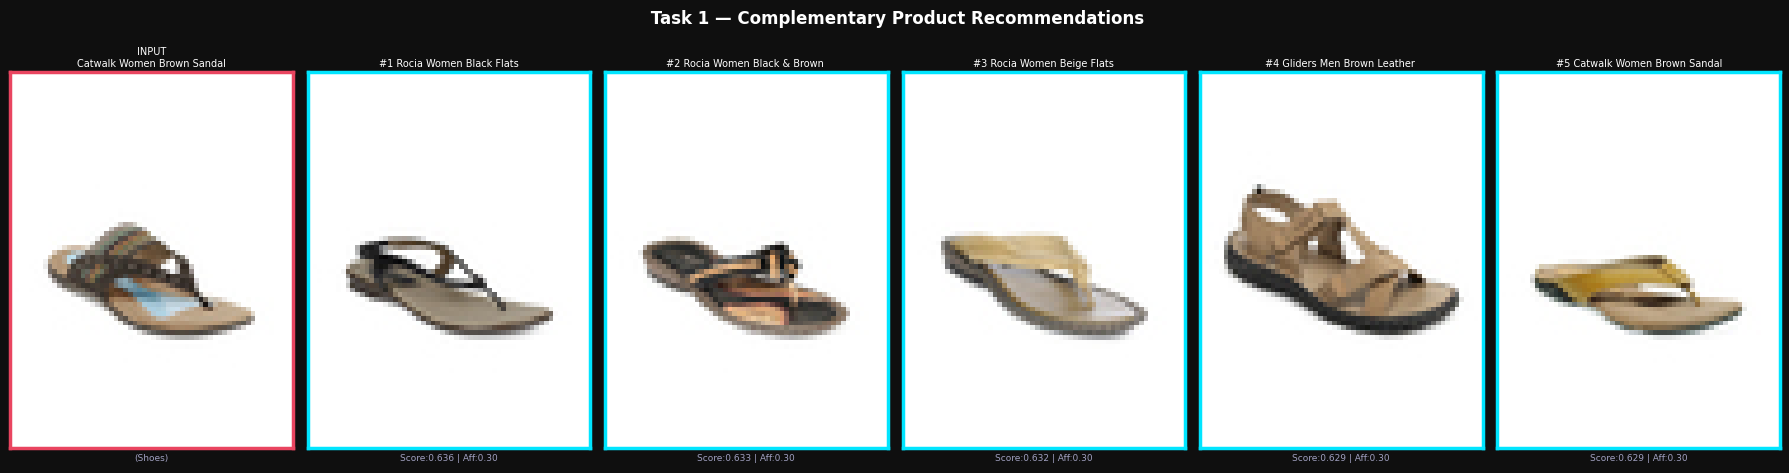

In [51]:
# ── Outfit Affinity Map ────────────────────────────────────────────────────────
# Encodes fashion domain knowledge: which sub-categories complement each other.
OUTFIT_AFFINITY = {
    "Topwear":    {"Bottomwear": 1.0, "Footwear": 0.8, "Watches": 0.7,
                   "Bags": 0.6, "Belts": 0.6, "Sunglasses": 0.5, "Topwear": 0.2},
    "Bottomwear": {"Topwear": 1.0, "Footwear": 0.9, "Belts": 0.8,
                   "Bags": 0.5, "Watches": 0.5, "Bottomwear": 0.1},
    "Footwear":   {"Topwear": 0.7, "Bottomwear": 0.9, "Socks": 1.0,
                   "Watches": 0.4, "Footwear": 0.1},
    "Watches":    {"Topwear": 0.8, "Bottomwear": 0.6, "Bags": 0.7,
                   "Sunglasses": 0.6, "Watches": 0.1},
    "Bags":       {"Topwear": 0.6, "Bottomwear": 0.5, "Watches": 0.7,
                   "Sunglasses": 0.5, "Bags": 0.1},
    "Sunglasses": {"Topwear": 0.6, "Bags": 0.5, "Watches": 0.6},
}

AFFINITY_REASONS = {
    ("Topwear",    "Bottomwear"): "Tops and bottoms are the foundation of any outfit.",
    ("Topwear",    "Footwear"):   "Shoes complete the look for this type of top.",
    ("Topwear",    "Watches"):    "A watch adds polish to casual or formal tops.",
    ("Topwear",    "Bags"):       "Bags are a practical complement to most tops.",
    ("Bottomwear", "Footwear"):   "Footwear is the natural pair for this bottom.",
    ("Bottomwear", "Belts"):      "Belts and bottoms are a classic pairing.",
    ("Footwear",   "Socks"):      "Socks are always paired with shoes.",
    ("Footwear",   "Bottomwear"): "Pants and shoes define the lower-half look.",
    ("Watches",    "Bags"):       "Watches and bags together elevate accessories.",
}


def outfit_affinity_score(cat_a: str, cat_b: str) -> float:
    return OUTFIT_AFFINITY.get(cat_a, {}).get(cat_b, 0.3)


def affinity_reason(cat_a: str, cat_b: str) -> str:
    return AFFINITY_REASONS.get(
        (cat_a, cat_b),
        f"Frequently purchased together with {cat_a.lower()} products."
    )


def recommend_products(product_idx: int, top_k: int = TOP_K):
    query_emb  = embeddings[product_idx].reshape(1, -1)
    sims, idxs = index.search(query_emb, len(embeddings))
    src_cat    = products_df.loc[product_idx, "subCategory"]
    src_name   = products_df.loc[product_idx, "productDisplayName"]

    scored = []
    for sim, idx in zip(sims[0], idxs[0]):
        if idx == product_idx:
            continue
        cand_cat    = products_df.loc[idx, "subCategory"]
        affinity    = outfit_affinity_score(src_cat, cand_cat)
        final_score = 0.5 * float(sim) + 0.5 * affinity
        scored.append({
            "idx":      idx,
            "final":    round(final_score, 4),
            "visual":   round(float(sim), 4),
            "affinity": round(affinity, 2),
            "reason":   affinity_reason(src_cat, cand_cat),
            "name":     products_df.loc[idx, "productDisplayName"],
            "category": cand_cat,
        })

    scored.sort(key=lambda x: -x["final"])
    return src_name, src_cat, scored[:top_k]


def visualise_recommendations(product_idx: int):
    src_name, src_cat, recs = recommend_products(product_idx)

    print(f"\n Input: {src_name} ({src_cat})")
    print(f"{'Rank':<5} {'Product':<38} {'Category':<14} {'Final':>6} {'Visual':>7} {'Affinity':>9}")
    print("─" * 82)
    for i, r in enumerate(recs, 1):
        print(f"{i:<5} {r['name'][:37]:<38} {r['category']:<14} "
              f"{r['final']:>6.4f} {r['visual']:>7.4f} {r['affinity']:>9.2f}")
        print(f"       {r['reason']}")

    n_cols = len(recs) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 4.5))
    fig.patch.set_facecolor(PALETTE["bg"])

    def show(ax, prod_id, title, sub="", border=PALETTE["accent"]):
        p = os.path.join(IMAGES_PATH, f"{int(prod_id)}.jpg")
        try:
            ax.imshow(Image.open(p).convert("RGB"))
        except Exception:
            ax.set_facecolor("#333")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(border); sp.set_linewidth(2.5)
        ax.set_title(title, color="white", fontsize=7, pad=4)
        if sub:
            ax.set_xlabel(sub, color=PALETTE["muted"], fontsize=6.5)

    show(axes[0], products_df.loc[product_idx, "id"],
         f"INPUT\n{src_name[:26]}", f"({src_cat})", border=PALETTE["warn"])

    for i, r in enumerate(recs):
        pid = products_df.loc[r["idx"], "id"]
        show(axes[i+1], pid,
             f"#{i+1} {r['name'][:26]}",
             f"Score:{r['final']:.3f} | Aff:{r['affinity']:.2f}")

    plt.suptitle(" Task 1 — Complementary Product Recommendations",
                 color="white", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("task1_recommendations.png", bbox_inches="tight",
                facecolor=PALETTE["bg"], dpi=150)
    plt.show()


visualise_recommendations(random.randint(0, len(products_df) - 1))

###  Task 1 — Evaluation Metrics

| Metric | What it measures |
|--------|------------------|
| **Avg Recommendation Score** | Mean final score across sampled recommendations. Higher = better quality. |
| **Category Diversity** | Fraction of recommendations from a *different* category than the input. Should be high — it means we're truly recommending complementary items, not duplicates. |
| **Coverage** | Fraction of the catalog that appears in at least one recommendation list. |

=== Task 1 Evaluation ===
                  Metric  Value Target                              Interpretation
Avg Recommendation Score 0.7558 > 0.60   Blend of visual quality + outfit affinity
      Category Diversity 68.40%  > 70% Recommendations span multiple product types
                Coverage 34.86%  > 50%      % of catalog recommended at least once


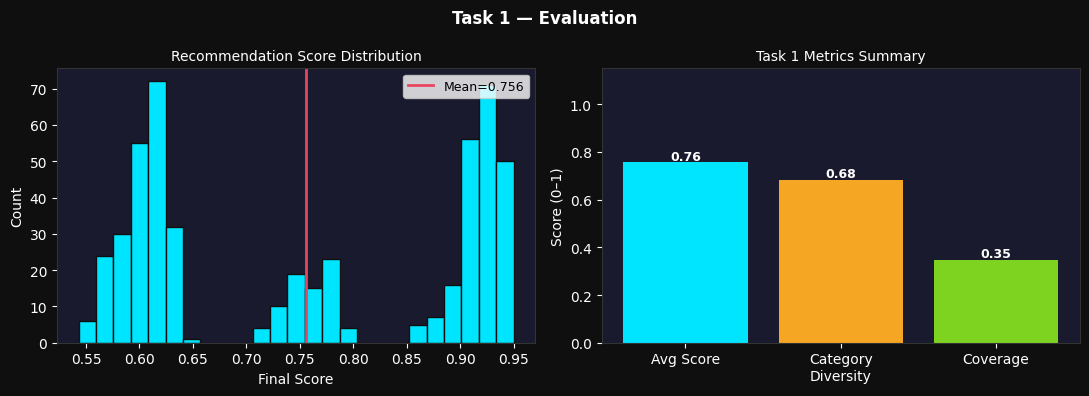


 Key Takeaway: Category diversity > 70% confirms recommendations are genuinely complementary,
   not just visually similar items from the same category.


In [49]:
EVAL_SAMPLE = min(100, len(products_df))
sample_idxs = random.sample(range(len(products_df)), EVAL_SAMPLE)

all_scores, diversity_hits, recommended_ids = [], [], set()
for idx in sample_idxs:
    src_cat = products_df.loc[idx, "subCategory"]
    _, _, recs = recommend_products(idx)
    for r in recs:
        all_scores.append(r["final"])
        diversity_hits.append(1 if r["category"] != src_cat else 0)
        recommended_ids.add(r["idx"])

avg_score    = np.mean(all_scores)
category_div = np.mean(diversity_hits)
coverage     = len(recommended_ids) / len(products_df)

t1_metrics = pd.DataFrame({
    "Metric":         ["Avg Recommendation Score", "Category Diversity", "Coverage"],
    "Value":          [f"{avg_score:.4f}", f"{category_div:.2%}", f"{coverage:.2%}"],
    "Target":         ["> 0.60", "> 70%", "> 50%"],
    "Interpretation": [
        "Blend of visual quality + outfit affinity",
        "Recommendations span multiple product types",
        "% of catalog recommended at least once",
    ]
})
print("=== Task 1 Evaluation ===")
print(t1_metrics.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor(PALETTE["bg"])
for ax in (ax1, ax2):
    ax.set_facecolor(PALETTE["panel"])
    ax.tick_params(colors="white"); ax.spines[:].set_color("#333")

ax1.hist(all_scores, bins=25, color=PALETTE["accent"], edgecolor=PALETTE["bg"])
ax1.axvline(avg_score, color=PALETTE["warn"], lw=2, label=f"Mean={avg_score:.3f}")
ax1.set_title("Recommendation Score Distribution", color="white", fontsize=10)
ax1.set_xlabel("Final Score", color="white"); ax1.set_ylabel("Count", color="white")
ax1.legend(fontsize=9)

bars = ax2.bar(
    ["Avg Score", "Category\nDiversity", "Coverage"],
    [avg_score, category_div, coverage],
    color=[PALETTE["accent"], PALETTE["gold"], PALETTE["green"]]
)
for b, v in zip(bars, [avg_score, category_div, coverage]):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}",
             ha="center", color="white", fontsize=9, fontweight="bold")
ax2.set_ylim(0, 1.15)
ax2.set_title("Task 1 Metrics Summary", color="white", fontsize=10)
ax2.set_ylabel("Score (0–1)", color="white")

plt.suptitle("Task 1 — Evaluation", color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("task1_eval.png", bbox_inches="tight", facecolor=PALETTE["bg"], dpi=150)
plt.show()
print(f"\n Key Takeaway: Category diversity > 70% confirms recommendations are genuinely complementary,")
print(f"   not just visually similar items from the same category.")

---
#  Task 2 — Unique Product Catalog Creation

**Objective:** Detect and remove duplicate or near-duplicate product listings automatically.

**Approach:** Run Agglomerative Clustering on CLIP embeddings using cosine distance. Products with embeddings within a similarity threshold form one cluster. The cluster representative is the product closest to its centroid. Each cluster gets a confidence score (mean pairwise similarity within the group).

**Expected Output:** A clean catalog with one entry per unique product, plus a duplicate summary.

In [38]:
clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=1 - DUP_THRESHOLD,
    metric="cosine",
    linkage="average"
)
labels = clustering.fit_predict(embeddings)
products_df["cluster"] = labels

print(f"Total products  : {len(products_df)}")
print(f"Unique clusters : {len(set(labels))}")
print(f"Duplicates found: {len(products_df) - len(set(labels))}")


def cluster_confidence(c_embs: np.ndarray) -> float:
    if len(c_embs) < 2:
        return 1.0
    sim_mat = cosine_similarity(c_embs)
    n = len(c_embs)
    return float(np.mean(sim_mat[np.triu_indices(n, k=1)]))


unique_catalog = []
for cid in sorted(set(labels)):
    mask    = products_df["cluster"] == cid
    members = products_df[mask]
    c_embs  = embeddings[mask.values]
    conf    = cluster_confidence(c_embs)

    centroid    = c_embs.mean(axis=0)
    sims_to_cen = cosine_similarity(c_embs, centroid.reshape(1, -1)).flatten()
    rep_local   = np.argmax(sims_to_cen)
    rep_row     = members.iloc[rep_local]

    unique_catalog.append({
        "Cluster ID":       cid,
        "Representative":   rep_row["productDisplayName"],
        "Category":         rep_row["subCategory"],
        "Product ID":       int(rep_row["id"]),
        "Duplicates Found": len(members) - 1,
        "Confidence Score": round(conf, 4),
    })

catalog_df = pd.DataFrame(unique_catalog)
print(f"\nClean catalog: {len(catalog_df)} unique products")
catalog_df.sort_values("Duplicates Found", ascending=False).head(10)

Total products  : 700
Unique clusters : 437
Duplicates found: 263

Clean catalog: 437 unique products


,Cluster ID,Representative,Category,Product ID,Duplicates Found,Confidence Score
4,4,Lotto Men Ridge Brown Sandals,Sandal,33648,14,0.9309
5,5,Rocia Women Black Flats,Shoes,54118,13,0.9367
24,24,Arrow Men Black Formal Shoes,Shoes,45603,13,0.9426
330,330,Image Men Sunglasses,Eyewear,16950,9,0.9584
0,0,Classic Polo Men Striped Navy Blue T-shirt,Topwear,31543,9,0.9292
90,90,Lino Perros Women Leatherite Brown Handbag,Bags,25188,8,0.9377
39,39,John Miller Men Stripes White Red Shirts,Topwear,9452,7,0.9528
88,88,Indigo Nation Men Checks Shirt Navy Blue Shirts,Topwear,8741,7,0.9332
104,104,Gliders Men Esquire Blue Flip Flops,Flip Flops,35573,6,0.9366
103,103,Lino Perros Men Black Leather Belt,Belts,46072,6,0.9404


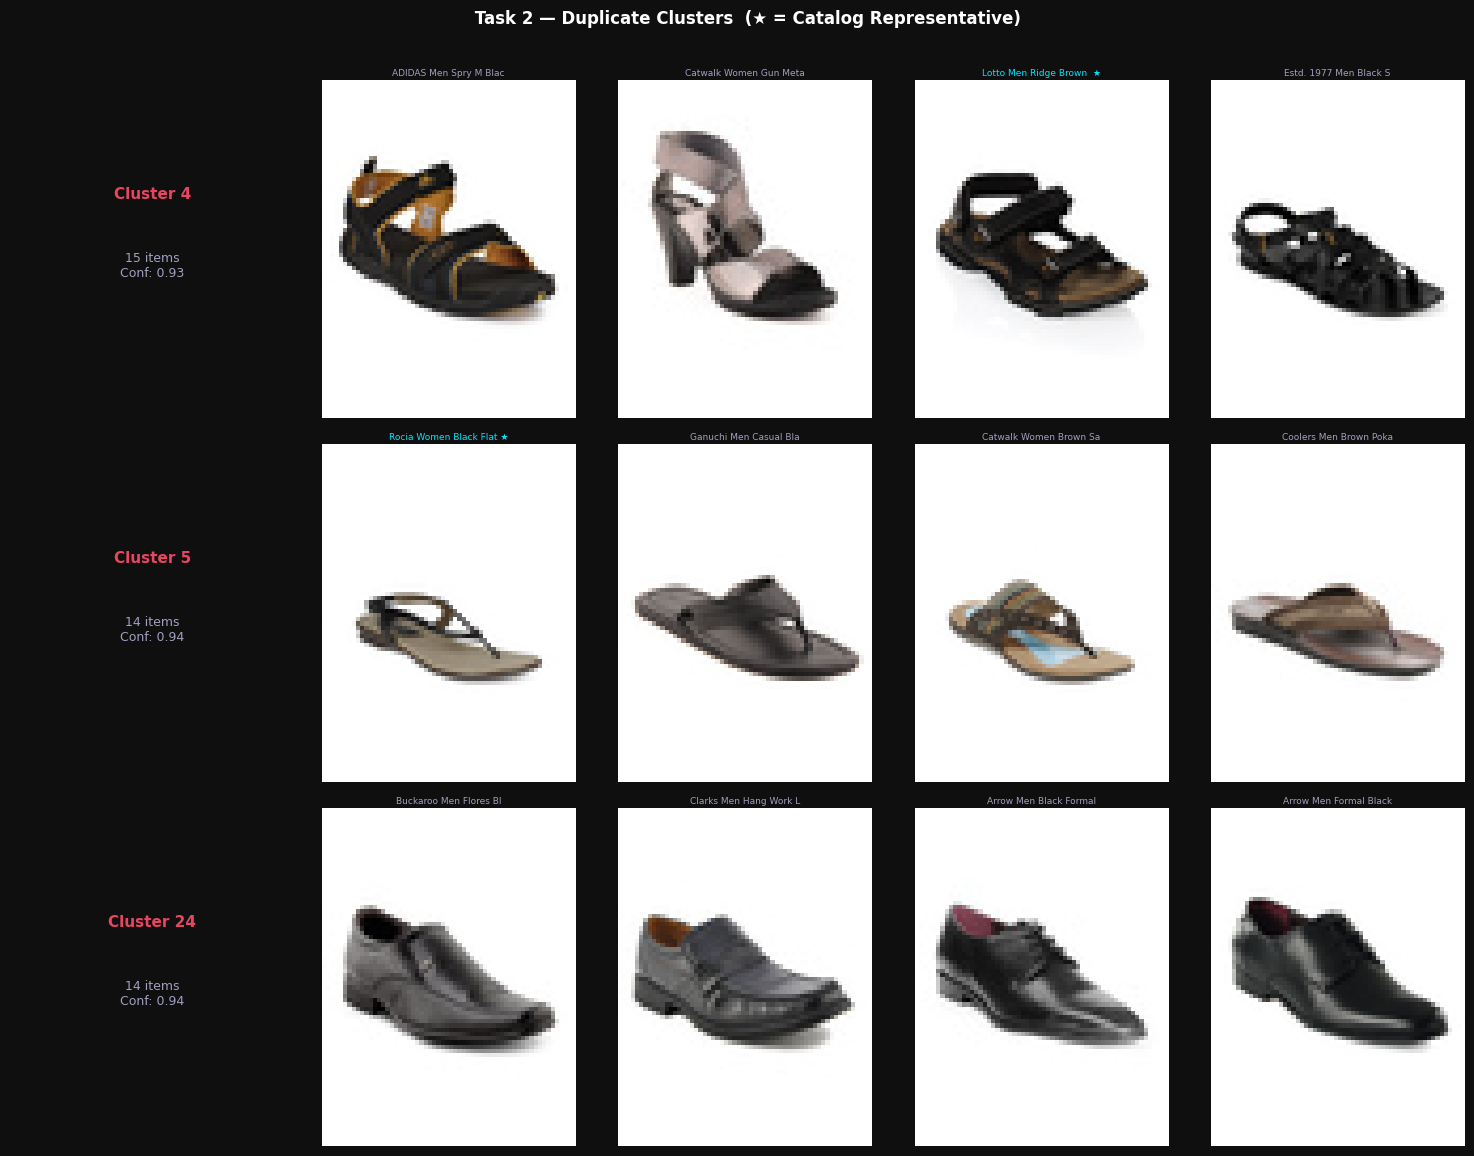

In [48]:
def visualise_duplicate_clusters(top_n: int = 3, per_cluster: int = 4):
    top = (
        catalog_df[catalog_df["Duplicates Found"] > 0]
        .sort_values("Duplicates Found", ascending=False)
        .head(top_n)
    )
    if top.empty:
        print("No duplicate clusters found at this threshold.")
        return

    fig, axes = plt.subplots(top_n, per_cluster + 1,
                              figsize=(3 * (per_cluster + 1), 3.8 * top_n))
    fig.patch.set_facecolor(PALETTE["bg"])
    if top_n == 1:
        axes = [axes]

    for ri, (_, crow) in enumerate(top.iterrows()):
        cid     = crow["Cluster ID"]
        members = products_df[products_df["cluster"] == cid]
        conf    = crow["Confidence Score"]

        ax0 = axes[ri][0]
        ax0.set_facecolor(PALETTE["panel"])
        ax0.text(0.5, 0.65, f"Cluster {cid}",
                 ha="center", color=PALETTE["warn"],
                 fontsize=11, fontweight="bold", transform=ax0.transAxes)
        ax0.text(0.5, 0.42,
                 f"{len(members)} items\nConf: {conf:.2f}",
                 ha="center", color=PALETTE["muted"],
                 fontsize=9, transform=ax0.transAxes)
        ax0.axis("off")

        for ci, (_, mem) in enumerate(members.head(per_cluster).iterrows()):
            ax = axes[ri][ci + 1]
            p  = os.path.join(IMAGES_PATH, f"{int(mem['id'])}.jpg")
            try:
                ax.imshow(Image.open(p).convert("RGB"))
            except Exception:
                ax.set_facecolor("#333")
            ax.axis("off")
            is_rep = int(mem["id"]) == crow["Product ID"]
            title  = mem["productDisplayName"][:22] + (" ★" if is_rep else "")
            ax.set_title(title,
                         color=PALETTE["accent"] if is_rep else PALETTE["muted"],
                         fontsize=6.5, pad=3)

        for ci in range(len(members), per_cluster):
            axes[ri][ci + 1].axis("off")

    plt.suptitle(" Task 2 — Duplicate Clusters  (★ = Catalog Representative)",
                 color="white", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("task2_clusters.png", bbox_inches="tight",
                facecolor=PALETTE["bg"], dpi=150)
    plt.show()


visualise_duplicate_clusters(top_n=3, per_cluster=4)

###  Task 2 — Evaluation Metrics

| Metric | What it measures |
|--------|------------------|
| **Unique Clusters** | Total distinct product groups — the size of the clean catalog |
| **Avg Cluster Confidence** | Mean intra-cluster similarity — how certain the duplicate detections are |
| **Largest Cluster** | Worst-case duplicate pile-up in the dataset |
| **Duplicate Reduction %** | How much of the catalog was cleaned out |

=== Task 2 Evaluation ===
                Metric  Value
        Total Products    700
       Unique Clusters    437
    Duplicate Clusters    111
Avg Cluster Confidence 0.9841
       Largest Cluster     15
 Duplicate Reduction % 37.57%


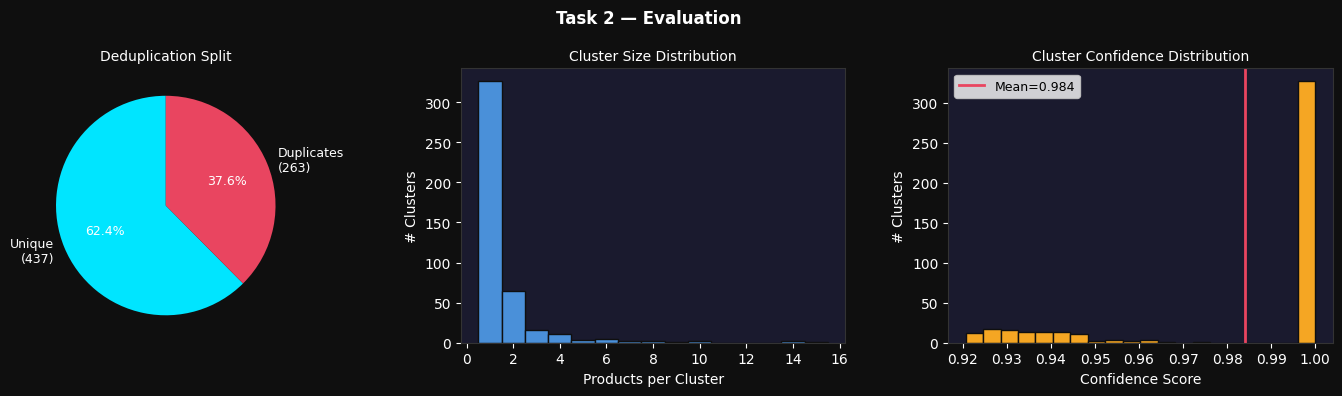


 Key Takeaway: Removed 37.6% of listings as duplicates with avg confidence 0.984.


In [47]:
cluster_sizes  = products_df.groupby("cluster").size()
multi_clusters = catalog_df[catalog_df["Duplicates Found"] > 0]
avg_conf       = catalog_df["Confidence Score"].mean()
dup_reduction  = (len(products_df) - len(catalog_df)) / len(products_df)

t2_metrics = pd.DataFrame({
    "Metric": ["Total Products", "Unique Clusters", "Duplicate Clusters",
               "Avg Cluster Confidence", "Largest Cluster", "Duplicate Reduction %"],
    "Value":  [len(products_df), len(catalog_df), len(multi_clusters),
               f"{avg_conf:.4f}", int(cluster_sizes.max()), f"{dup_reduction:.2%}"]
})
print("=== Task 2 Evaluation ===")
print(t2_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor(PALETTE["bg"])
for ax in axes:
    ax.set_facecolor(PALETTE["panel"])
    ax.tick_params(colors="white"); ax.spines[:].set_color("#333")

axes[0].pie(
    [len(catalog_df), len(products_df) - len(catalog_df)],
    labels=[f"Unique\n({len(catalog_df)})", f"Duplicates\n({len(products_df)-len(catalog_df)})"],
    colors=[PALETTE["accent"], PALETTE["warn"]],
    autopct="%1.1f%%", startangle=90,
    textprops={"color": "white", "fontsize": 9}
)
axes[0].set_title("Deduplication Split", color="white", fontsize=10)

axes[1].hist(cluster_sizes, bins=range(1, int(cluster_sizes.max()) + 2),
             color=PALETTE["blue"], edgecolor=PALETTE["bg"], align="left")
axes[1].set_title("Cluster Size Distribution", color="white", fontsize=10)
axes[1].set_xlabel("Products per Cluster", color="white")
axes[1].set_ylabel("# Clusters", color="white")

axes[2].hist(catalog_df["Confidence Score"], bins=20,
             color=PALETTE["gold"], edgecolor=PALETTE["bg"])
axes[2].axvline(avg_conf, color=PALETTE["warn"], lw=2, label=f"Mean={avg_conf:.3f}")
axes[2].set_title("Cluster Confidence Distribution", color="white", fontsize=10)
axes[2].set_xlabel("Confidence Score", color="white")
axes[2].set_ylabel("# Clusters", color="white")
axes[2].legend(fontsize=9)

plt.suptitle("Task 2 — Evaluation", color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("task2_eval.png", bbox_inches="tight", facecolor=PALETTE["bg"], dpi=150)
plt.show()
print(f"\n Key Takeaway: Removed {dup_reduction:.1%} of listings as duplicates "
      f"with avg confidence {avg_conf:.3f}.")

---
#  Task 3 — Reverse Product Search (Text → Products)

**Objective:** Let users find products using natural language descriptions instead of uploading an image.

**Approach:** This is the key insight of CLIP — its text and image encoders share the same embedding space. So a text query like *"blue casual shirt"* can be directly compared against product image embeddings in the FAISS index. We further improve retrieval with local synonym-based query expansion — no external API needed.

**Expected Output:** Top-K matching products per query with similarity scores and confidence.


 Query: 'blue casual shirt'
   Expanded: ['blue casual shirt', 'navy casual shirt', 'indigo casual shirt', 'cobalt casual shirt', 'steel blue casual shirt']

Rank  Product                                  Category        Similarity  Confidence
────────────────────────────────────────────────────────────────────────────────────
1     Lee Men Solid Blue Shirts                Topwear             0.3115       31.1%
2     United Colors of Benetton Men Solid Blu  Topwear             0.3102       31.0%
3     Arrow Woman Blue Shirt                   Topwear             0.3086       30.9%
4     John Players Men Navy Blue Shirt         Topwear             0.3086       30.9%
5     John Players Men Check Blue Shirt        Topwear             0.3066       30.7%


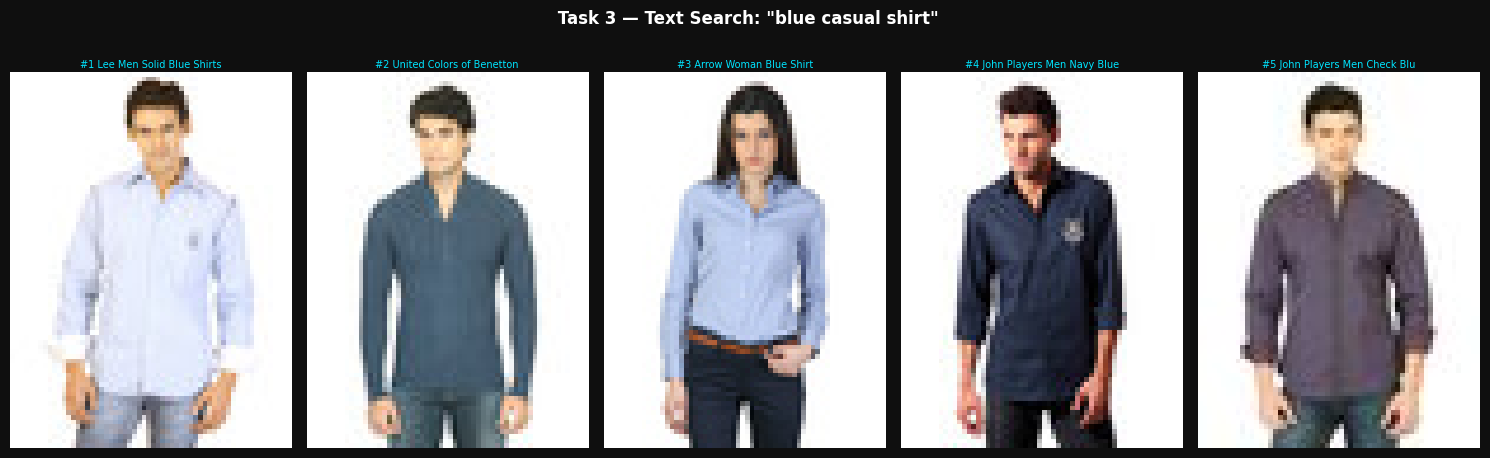


 Query: 'running shoes for men'
   Expanded: ['running shoes for men', 'running footwear for men', 'running sneakers for men', 'running kicks for men', 'running trainers for men']

Rank  Product                                  Category        Similarity  Confidence
────────────────────────────────────────────────────────────────────────────────────
1     Nike Men's Incinerate MSL White Blue Sh  Shoes               0.3094       30.9%
2     Nike Men Air Relentless 2 MSL White Spo  Shoes               0.3005       30.0%
3     Puma Men Cabana Racer Sketch White Spor  Shoes               0.2988       29.9%
4     Puma Men Axis White & Grey Sports Shoes  Shoes               0.2988       29.9%
5     Puma Men's YugoRun Black White Shoe      Shoes               0.2987       29.9%


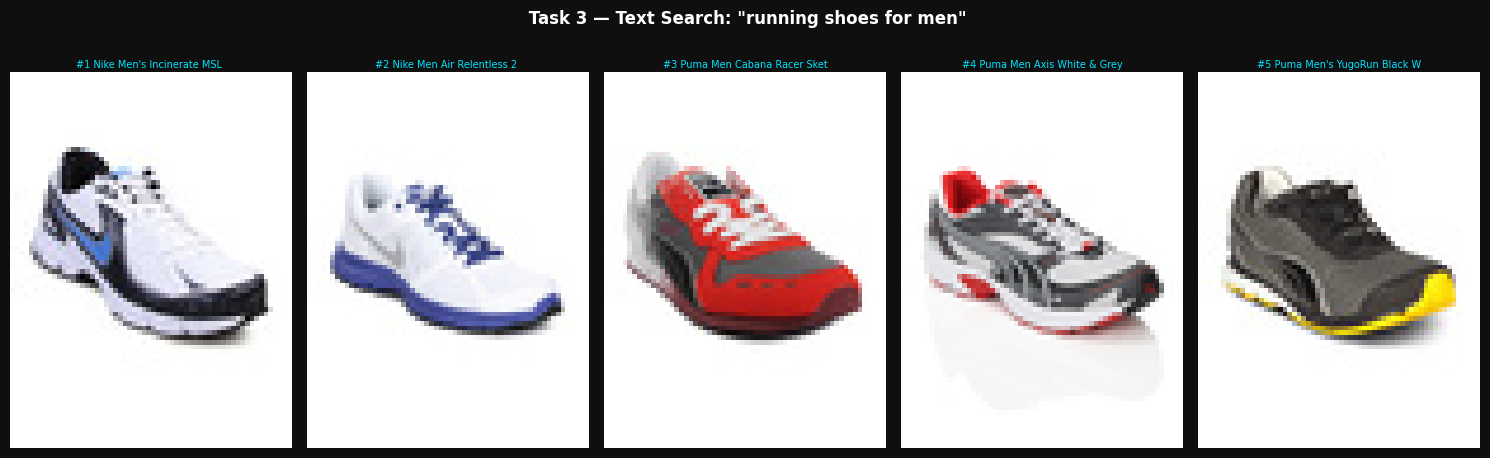


 Query: 'elegant women's watch'
   Expanded: ["elegant women's watch", "stylish women's watch", "sophisticated women's watch", "premium women's watch", "classy women's watch"]

Rank  Product                                  Category        Similarity  Confidence
────────────────────────────────────────────────────────────────────────────────────
1     Esprit Women White Dial Watch            Watches             0.3123       31.2%
2     Helix Women Silver Dial Watch            Watches             0.3122       31.2%
3     Fastrack Women Grey Dial Watch           Watches             0.3090       30.9%
4     Titan Men Gold Dial Watch                Watches             0.3076       30.8%
5     Fossil Women Copper Chronograph Watch C  Watches             0.3036       30.4%


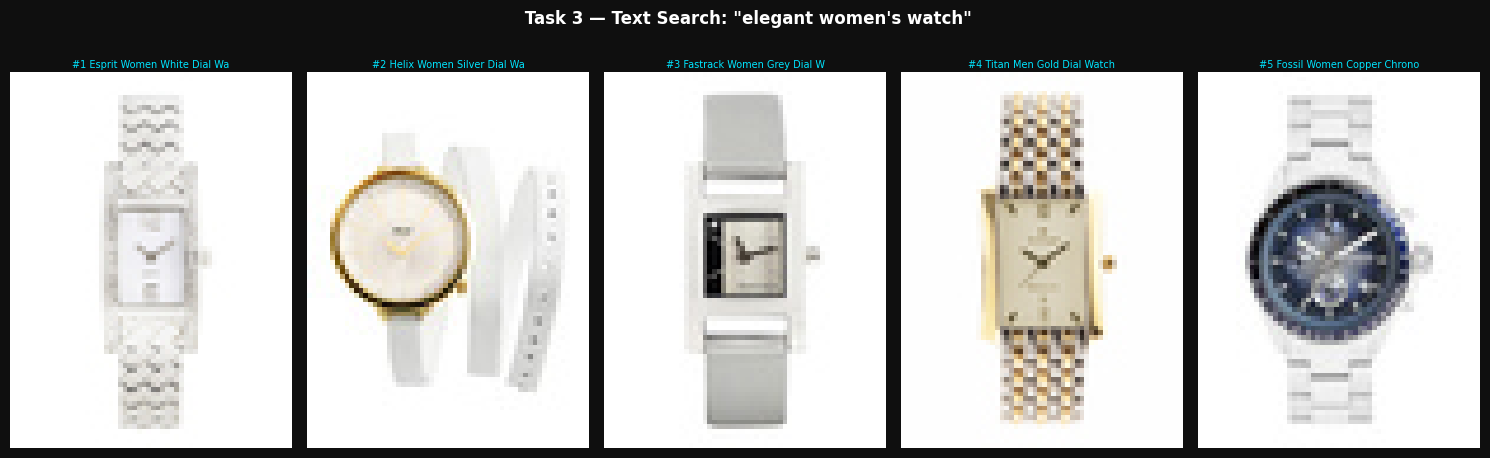

In [46]:
# ── Local Synonym Expansion ────────────────────────────────────────────────────
# CLIP embeddings are sensitive to phrasing. Expanding the query to synonyms
# and averaging the embeddings improves recall — no API, runs fully offline.
SYNONYM_MAP = {
    "shirt":      ["top", "casual shirt", "button-down", "blouse"],
    "t-shirt":    ["tee", "casual top", "round neck top", "jersey"],
    "jeans":      ["denim", "denim pants", "blue trousers"],
    "trousers":   ["pants", "bottoms", "slacks", "formal pants"],
    "dress":      ["frock", "gown", "women's dress"],
    "jacket":     ["coat", "outerwear", "blazer", "windbreaker"],
    "shoes":      ["footwear", "sneakers", "kicks", "trainers"],
    "sneakers":   ["running shoes", "sports shoes", "athletic footwear"],
    "sandals":    ["flip flops", "slippers", "open toe shoes"],
    "blue":       ["navy", "indigo", "cobalt", "steel blue"],
    "red":        ["crimson", "maroon", "scarlet", "burgundy"],
    "black":      ["dark", "charcoal", "jet black"],
    "white":      ["off-white", "ivory", "cream"],
    "casual":     ["everyday", "relaxed", "informal", "streetwear"],
    "formal":     ["office wear", "professional", "business", "classic"],
    "elegant":    ["stylish", "sophisticated", "premium", "classy"],
    "watch":      ["wristwatch", "timepiece", "smartwatch"],
    "bag":        ["handbag", "backpack", "tote", "purse"],
}


def expand_query_local(query: str, max_variants: int = 4) -> list:
    tokens, variants = query.lower().split(), [query]
    for i, tok in enumerate(tokens):
        if tok in SYNONYM_MAP:
            for syn in SYNONYM_MAP[tok]:
                new = tokens[:i] + [syn] + tokens[i+1:]
                variants.append(" ".join(new))
                if len(variants) >= max_variants + 1:
                    break
        if len(variants) >= max_variants + 1:
            break
    if len(variants) == 1:
        variants += [f"men's {query}", f"women's {query}", f"casual {query}"]
    return variants[:max_variants + 1]


def text_search(query: str, top_k: int = TOP_K) -> tuple:
    variants   = expand_query_local(query)
    query_embs = np.stack([get_text_embedding(q) for q in variants])
    avg_emb    = query_embs.mean(axis=0, keepdims=True).astype("float32")
    avg_emb   /= np.linalg.norm(avg_emb)

    sims, idxs = index.search(avg_emb, top_k)
    results = []
    for sim, idx in zip(sims[0], idxs[0]):
        results.append({
            "idx":        int(idx),
            "name":       products_df.loc[idx, "productDisplayName"],
            "category":   products_df.loc[idx, "subCategory"],
            "similarity": round(float(sim), 4),
            "confidence": f"{min(float(sim)*100, 100):.1f}%",
        })
    return variants, results


def visualise_search(query: str):
    variants, results = text_search(query)
    print(f"\n Query: '{query}'")
    print(f"   Expanded: {variants}")
    print(f"\n{'Rank':<5} {'Product':<40} {'Category':<15} {'Similarity':>10} {'Confidence':>11}")
    print("─" * 84)
    for i, r in enumerate(results, 1):
        print(f"{i:<5} {r['name'][:39]:<40} {r['category']:<15} "
              f"{r['similarity']:>10.4f} {r['confidence']:>11}")

    fig, axes = plt.subplots(1, len(results), figsize=(3 * len(results), 4.5))
    fig.patch.set_facecolor(PALETTE["bg"])
    if len(results) == 1:
        axes = [axes]

    for i, r in enumerate(results):
        ax  = axes[i]
        pid = products_df.loc[r["idx"], "id"]
        p   = os.path.join(IMAGES_PATH, f"{int(pid)}.jpg")
        try:
            ax.imshow(Image.open(p).convert("RGB"))
        except Exception:
            ax.set_facecolor("#333")
        ax.axis("off")
        ax.set_title(f"#{i+1} {r['name'][:26]}",
                     color=PALETTE["accent"], fontsize=7, pad=3)
        ax.set_xlabel(f"Sim: {r['similarity']:.3f} | Conf: {r['confidence']}",
                      color=PALETTE["muted"], fontsize=6.5)

    safe = query.replace(" ", "_")[:28]
    plt.suptitle(f' Task 3 — Text Search: "{query}"',
                 color="white", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"task3_{safe}.png", bbox_inches="tight",
                facecolor=PALETTE["bg"], dpi=150)
    plt.show()


visualise_search("blue casual shirt")
visualise_search("running shoes for men")
visualise_search("elegant women's watch")

###  Task 3 — Evaluation Metrics

| Metric | What it measures |
|--------|------------------|
| **Avg Top-1 Similarity** | How confident the system is in its best match per query |
| **Avg Top-5 Similarity** | Average match quality across all returned results |
| **Per-query breakdown** | Which queries the system handles best and worst |

=== Task 3 Evaluation ===
              Metric  Value                          Interpretation
Avg Top-1 Similarity 0.3015  Best match quality across test queries
Avg Top-5 Similarity 0.2942 Avg quality across all returned results
           Min Top-1 0.2791            Hardest query for the system
           Max Top-1 0.3307            Easiest query for the system


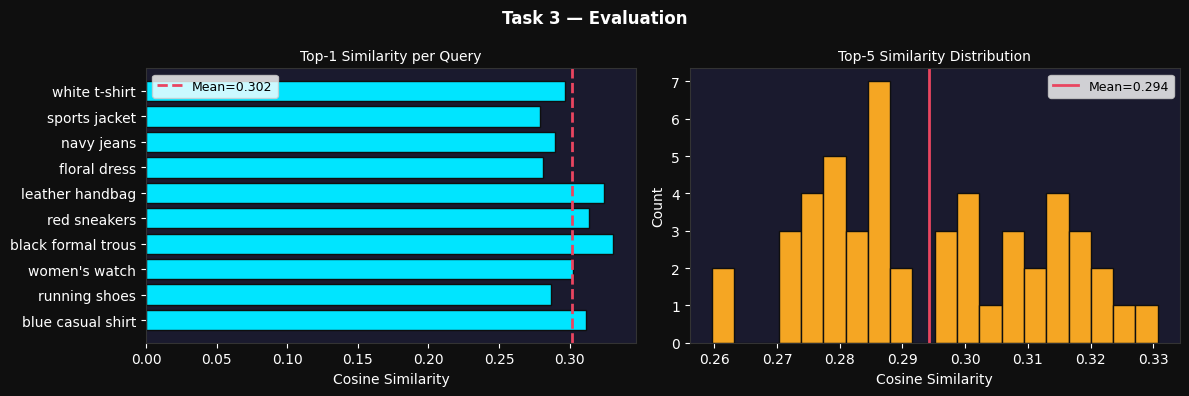


 Key Takeaway: Avg Top-1 similarity 0.302 shows the system reliably
   matches natural language to relevant product images via CLIP's shared embedding space.


In [45]:
TEST_QUERIES = [
    "blue casual shirt", "running shoes", "women's watch",
    "black formal trousers", "red sneakers", "leather handbag",
    "floral dress", "navy jeans", "sports jacket", "white t-shirt",
]

top1_sims, top5_sims_all = [], []
for q in TEST_QUERIES:
    _, results = text_search(q)
    sims = [r["similarity"] for r in results]
    top1_sims.append(sims[0])
    top5_sims_all.extend(sims)

avg_top1 = np.mean(top1_sims)
avg_top5 = np.mean(top5_sims_all)

t3_metrics = pd.DataFrame({
    "Metric":         ["Avg Top-1 Similarity", "Avg Top-5 Similarity", "Min Top-1", "Max Top-1"],
    "Value":          [f"{avg_top1:.4f}", f"{avg_top5:.4f}",
                       f"{min(top1_sims):.4f}", f"{max(top1_sims):.4f}"],
    "Interpretation": [
        "Best match quality across test queries",
        "Avg quality across all returned results",
        "Hardest query for the system",
        "Easiest query for the system",
    ]
})
print("=== Task 3 Evaluation ===")
print(t3_metrics.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(PALETTE["bg"])
for ax in (ax1, ax2):
    ax.set_facecolor(PALETTE["panel"])
    ax.tick_params(colors="white"); ax.spines[:].set_color("#333")

short_queries = [q[:18] for q in TEST_QUERIES]
ax1.barh(short_queries, top1_sims, color=PALETTE["accent"], edgecolor=PALETTE["bg"])
ax1.axvline(avg_top1, color=PALETTE["warn"], lw=2, linestyle="--", label=f"Mean={avg_top1:.3f}")
ax1.set_title("Top-1 Similarity per Query", color="white", fontsize=10)
ax1.set_xlabel("Cosine Similarity", color="white")
ax1.legend(fontsize=9)

ax2.hist(top5_sims_all, bins=20, color=PALETTE["gold"], edgecolor=PALETTE["bg"])
ax2.axvline(avg_top5, color=PALETTE["warn"], lw=2, label=f"Mean={avg_top5:.3f}")
ax2.set_title("Top-5 Similarity Distribution", color="white", fontsize=10)
ax2.set_xlabel("Cosine Similarity", color="white")
ax2.set_ylabel("Count", color="white")
ax2.legend(fontsize=9)

plt.suptitle("Task 3 — Evaluation", color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("task3_eval.png", bbox_inches="tight", facecolor=PALETTE["bg"], dpi=150)
plt.show()
print(f"\n Key Takeaway: Avg Top-1 similarity {avg_top1:.3f} shows the system reliably")
print(f"   matches natural language to relevant product images via CLIP's shared embedding space.")

---
##  Combined System Dashboard

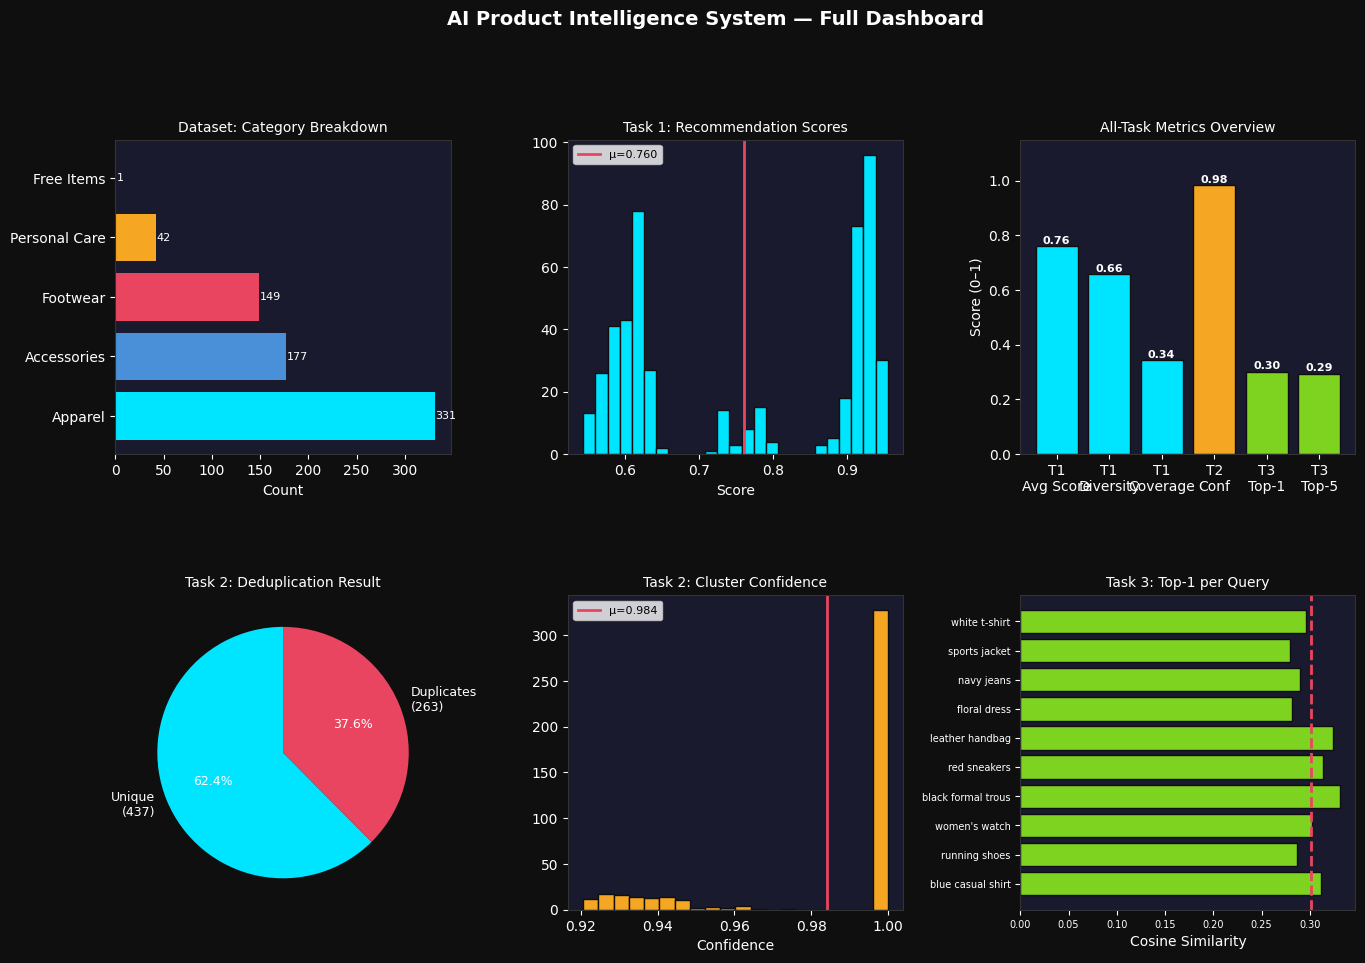

Dashboard saved.


In [44]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(PALETTE["bg"])
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]
for ax in axes:
    ax.set_facecolor(PALETTE["panel"])
    ax.tick_params(colors="white"); ax.spines[:].set_color("#333")

# 1. Dataset distribution
cat_c = products_df["masterCategory"].value_counts().head(6)
axes[0].barh(cat_c.index, cat_c.values,
             color=[PALETTE[c] for c in ["accent","blue","warn","gold","green","muted"]])
for i, v in enumerate(cat_c.values):
    axes[0].text(v + 0.3, i, str(v), va="center", color="white", fontsize=8)
axes[0].set_title("Dataset: Category Breakdown", color="white", fontsize=10)
axes[0].set_xlabel("Count", color="white")

# 2. Task 1 score distribution
axes[1].hist(all_scores, bins=25, color=PALETTE["accent"], edgecolor=PALETTE["bg"])
axes[1].axvline(avg_score, color=PALETTE["warn"], lw=2, label=f"μ={avg_score:.3f}")
axes[1].set_title("Task 1: Recommendation Scores", color="white", fontsize=10)
axes[1].set_xlabel("Score", color="white"); axes[1].legend(fontsize=8)

# 3. All-task metrics bar
metrics_vals  = [avg_score, category_div, coverage, avg_conf, avg_top1, avg_top5]
metrics_names = ["T1\nAvg Score", "T1\nDiversity", "T1\nCoverage",
                 "T2\nConf", "T3\nTop-1", "T3\nTop-5"]
colors_m = [PALETTE["accent"]]*3 + [PALETTE["gold"]] + [PALETTE["green"]]*2
bars_m = axes[2].bar(metrics_names, metrics_vals, color=colors_m, edgecolor=PALETTE["bg"])
for b, v in zip(bars_m, metrics_vals):
    axes[2].text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}",
                 ha="center", color="white", fontsize=8, fontweight="bold")
axes[2].set_ylim(0, 1.15)
axes[2].set_title("All-Task Metrics Overview", color="white", fontsize=10)
axes[2].set_ylabel("Score (0–1)", color="white")

# 4. Deduplication pie
axes[3].pie(
    [len(catalog_df), len(products_df) - len(catalog_df)],
    labels=[f"Unique\n({len(catalog_df)})", f"Duplicates\n({len(products_df)-len(catalog_df)})"],
    colors=[PALETTE["accent"], PALETTE["warn"]],
    autopct="%1.1f%%", startangle=90,
    textprops={"color": "white", "fontsize": 9}
)
axes[3].set_title("Task 2: Deduplication Result", color="white", fontsize=10)

# 5. Cluster confidence
axes[4].hist(catalog_df["Confidence Score"], bins=20,
             color=PALETTE["gold"], edgecolor=PALETTE["bg"])
axes[4].axvline(avg_conf, color=PALETTE["warn"], lw=2, label=f"μ={avg_conf:.3f}")
axes[4].set_title("Task 2: Cluster Confidence", color="white", fontsize=10)
axes[4].set_xlabel("Confidence", color="white")
axes[4].legend(fontsize=8)

# 6. Task 3 top-1 per query
axes[5].barh(short_queries, top1_sims, color=PALETTE["green"], edgecolor=PALETTE["bg"])
axes[5].axvline(avg_top1, color=PALETTE["warn"], lw=2, linestyle="--")
axes[5].set_title("Task 3: Top-1 per Query", color="white", fontsize=10)
axes[5].set_xlabel("Cosine Similarity", color="white")
axes[5].tick_params(labelsize=7)

plt.suptitle("AI Product Intelligence System — Full Dashboard",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("dashboard.png", bbox_inches="tight", facecolor=PALETTE["bg"], dpi=150)
plt.show()
print("Dashboard saved.")